# Домашнее задание к семинару 13 (HW13)

**Тема:** токенизация текста, инференс готовой BERT-подобной модели и базовый fine-tuning для классификации текста.

**Цель**

Закрепить:
- базовые принципы токенизации текста для трансформеров;
- практику инференса готовой BERT-подобной модели;
- базовый пайплайн fine-tuning для задачи классификации текста;
- аккуратное оформление результата: один ноутбук, короткий отчёт, минимальные артефакты.

### 1. Импорты, seed и среда

##### 1.1. Импортировать библиотеки: datasets, transformers, torch, numpy, pandas, sklearn, matplotlib (и всё, что нужно по делу).

In [20]:
import random
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

##### 1.2. Зафиксировать seed (минимум random, numpy, torch).

In [2]:
SEED = 666
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

##### 1.3. Определить устройство (cuda при наличии, иначе cpu) и использовать его последовательно.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


### 2. Данные и первичный анализ

##### 2.1. Загрузить выбранный датасет

In [4]:
dataset = load_dataset("emotion")

In [5]:
print("train:", len(dataset["train"]))
print("validation:", len(dataset["validation"]))
print("test:", len(dataset["test"]))

train: 16000
validation: 2000
test: 2000


##### 2.2. Показать размеры split-частей

In [6]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


##### 2.3. Вывести 3-5 примеров текстов и меток

In [7]:
label_names = dataset["train"].features["label"].names
print("Классы:", label_names)

for i in range(5):
    text = dataset["train"][i]["text"]
    label = dataset["train"][i]["label"]
    print(f"\nПример {i+1}:")
    print("Текст:", text)
    print("Метка:", label, "-", label_names[label])

Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Пример 1:
Текст: i didnt feel humiliated
Метка: 0 - sadness

Пример 2:
Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Метка: 0 - sadness

Пример 3:
Текст: im grabbing a minute to post i feel greedy wrong
Метка: 3 - anger

Пример 4:
Текст: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Метка: 2 - love

Пример 5:
Текст: i am feeling grouchy
Метка: 3 - anger


##### 2.4. Кратко пояснить, что именно классифицируется

Используется датасет emotion, содержащий короткие текстовые сообщения, размеченные по эмоциональным категориям. 

Задача заключается в классификации текста по одной из шести эмоций: sadness, joy, love, anger, fear, surprise

### 3. Токенизация

##### 3.1. Показать базовый разбор токенизации хотя бы для 3-5 текстов

- токены

In [8]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [9]:
examples = [dataset["train"][i]["text"] for i in range(3)]

batch = tokenizer(
    examples,
    padding=True,
    truncation=True,
    max_length=10,
    return_tensors="pt"
)

for i in range(len(examples)):
    print(f"\nBatch токены {i+1}:")
    print(tokenizer.convert_ids_to_tokens(batch["input_ids"][i].tolist()))


Batch токены 1:
['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]']

Batch токены 2:
['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', '[SEP]']

Batch токены 3:
['[CLS]', 'im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', '[SEP]']


- input_ids
- attention_mask

In [10]:
examples = [dataset["train"][i]["text"] for i in range(3)]

for i, text in enumerate(examples):
    encoding = tokenizer(text)

    print(f"\nПример {i+1}:")
    print("Исходный текст:", text)
    print("Токены:", tokenizer.convert_ids_to_tokens(encoding["input_ids"]))
    print("input_ids:", encoding["input_ids"])
    print("attention_mask:", encoding["attention_mask"])


Пример 1:
Исходный текст: i didnt feel humiliated
Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1]

Пример 2:
Исходный текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Токены: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Пример 3:
Исходный текст: im grabbing a minute to post i feel greedy wrong
Токены: ['[CLS]', 'im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wrong', '[SEP]']
input_ids: [101, 10047, 9775, 1037,

- special tokens

In [11]:
print("\nspecial tokens:")
print("CLS:", tokenizer.cls_token)
print("SEP:", tokenizer.sep_token)
print("PAD:", tokenizer.pad_token)
print("UNK:", tokenizer.unk_token)


special tokens:
CLS: [CLS]
SEP: [SEP]
PAD: [PAD]
UNK: [UNK]


- пример работы padding и/или truncation

In [12]:
print("\nBatch с padding/truncation:")
print("input_ids:\n", batch["input_ids"])
print("attention_mask:\n", batch["attention_mask"])


Batch с padding/truncation:
input_ids:
 tensor([[  101,  1045,  2134,  2102,  2514, 26608,   102,     0,     0,     0],
        [  101,  1045,  2064,  2175,  2013,  3110,  2061, 20625,  2000,   102],
        [  101, 10047,  9775,  1037,  3371,  2000,  2695,  1045,  2514,   102]])
attention_mask:
 tensor([[1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


### 4. Инференс готовой модели

##### 4.1. Запустить инференс готовой pretrained BERT-подобной модели на нескольких текстах

In [13]:
model_name = "distilbert-base-uncased-finetuned-sst-2-english"

model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


##### 4.2. Показать результаты хотя бы на 3-5 примерах

In [14]:
test_texts = [dataset["test"][i]["text"] for i in range(5)]

for i, text in enumerate(test_texts):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    probs = torch.softmax(logits, dim=1)

    pred_id = torch.argmax(probs, dim=1).item()
    pred_label = model.config.id2label[pred_id]
    confidence = probs[0][pred_id].item()

    print(f"\nПример {i+1}")
    print("Текст:", text)
    print("Предсказание:", pred_label)
    print("Уверенность:", round(confidence, 3))


Пример 1
Текст: im feeling rather rotten so im not very ambitious right now
Предсказание: NEGATIVE
Уверенность: 1.0

Пример 2
Текст: im updating my blog because i feel shitty
Предсказание: NEGATIVE
Уверенность: 0.999

Пример 3
Текст: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
Предсказание: POSITIVE
Уверенность: 0.999

Пример 4
Текст: i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived
Предсказание: POSITIVE
Уверенность: 0.987

Пример 5
Текст: i was feeling a little vain when i did this one
Предсказание: NEGATIVE
Уверенность: 1.0


##### 4.3. Кратко пояснить, насколько такая готовая модель подходит или не подходит под выбранную задачу

Для инференса используется предобученная модель, решающая задачу бинарной классификации тональности (позитив/негатив). Данная модель не обучалась на задаче классификации эмоций, поэтому её предсказания ограничены двумя классами.

Несмотря на это, модель способна улавливать общий эмоциональный тон текста, однако не различает конкретные эмоции, такие как страх, любовь или удивление.

Таким образом, готовая модель частично применима к задаче, но не соответствует ей полностью, что обосновывает необходимость fine-tuning на целевом датасете.

### 5. Fine-tuning для классификации текста

##### 5.1. Выбрать одну BERT-подобную модель

In [25]:
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

num_labels = len(label_names)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
model.to(device)

model.eval()
print(model)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


##### 5.2. Подготовить токенизацию датасета

In [26]:
def tokenize_fn(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_fn, batched=True)

small_train = tokenized_dataset["train"].select(range(500))
small_val   = tokenized_dataset["validation"].select(range(200))
small_test  = tokenized_dataset["test"].select(range(200))

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

##### 5.3. Обучить модель для sequence classification

In [27]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./artifacts",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_strategy="steps",
    logging_steps=50,
    save_strategy="no",
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    return {"accuracy": accuracy_score(labels, preds),
            "f1_macro": f1_score(labels, preds, average="macro")}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

D:\Projects\aiengine\homeworks\HW13\.venv\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
50,1.651909
100,1.490690


TrainOutput(global_step=126, training_loss=1.5345920683845642, metrics={'train_runtime': 750.5187, 'train_samples_per_second': 1.332, 'train_steps_per_second': 0.168, 'total_flos': 33119212032000.0, 'train_loss': 1.5345920683845642, 'epoch': 2.0})

### 6. Оценка качества и краткий анализ ошибок

##### 6.1. Один раз оценить лучший вариант на test

In [28]:
test_preds_output = trainer.predict(small_test)
y_true = test_preds_output.label_ids
y_pred = np.argmax(test_preds_output.predictions, axis=1)

##### 6.2. Посчитать метрики

In [33]:
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="macro")
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1_macro: {f1:.4f}")

Test Accuracy: 0.5650
Test F1_macro: 0.2361


##### 6.3. Построить матрицу ошибок

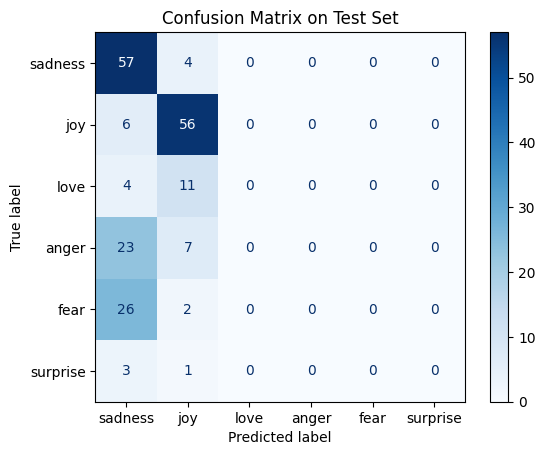

In [30]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(label_names))))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Test Set")
plt.savefig("./artifacts/confusion_matrix.png")
plt.show()

##### 6.4. Сохранить предсказания

In [31]:
sample_predictions = pd.DataFrame({
    "text": [x["text"] for x in small_test],
    "true_label": y_true,
    "pred_label": y_pred
})
sample_predictions.to_csv("./artifacts/sample_predictions.csv", index=False)

##### 6.5. Показать 5-10 примеров предсказаний модели

In [32]:
sample_output = sample_predictions.copy()
sample_output["correct"] = sample_output["true_label"] == sample_output["pred_label"]

print("Примеры ошибок:")
print(sample_output[sample_output["correct"]==False].head(5))

print("Примеры корректных предсказаний:")
print(sample_output[sample_output["correct"]==True].head(5))

Примеры ошибок:
                                                 text  true_label  pred_label  \
5   i cant walk into a shop anywhere where i do no...           4           0   
6    i felt anger when at the end of a telephone call           3           0   
7   i explain why i clung to a relationship with a...           1           0   
9   i jest i feel grumpy tired and pre menstrual w...           3           0   
10                 i don t feel particularly agitated           4           0   

    correct  
5     False  
6     False  
7     False  
9     False  
10    False  
Примеры корректных предсказаний:
                                                text  true_label  pred_label  \
0  im feeling rather rotten so im not very ambiti...           0           0   
1          im updating my blog because i feel shitty           0           0   
2  i never make her separate from me because i do...           0           0   
3  i left with my bouquet of red and yellow tulip...        

##### 6.6. Кратко прокомментировать несколько ошибок или пограничных случаев

Модель демонстрирует удовлетворительное распознавание наиболее частых эмоций (например, 0), однако испытывает трудности с менее представленными или более сложными классами (3 и 4), что отражается в смещении предсказаний в сторону класса 0. Ошибки часто связаны с эмоционально многозначными или размытыми текстами, где тональность выражена косвенно. Корректные предсказания чаще встречаются на явных, эмоционально насыщенных выражениях. В целом, модель способна выделять простые, явно выраженные эмоции, но требует дообучения или увеличения тренировочного объема для более редких и сложных категорий.